<a href="https://colab.research.google.com/github/ramanji567/Eda-checklist_ramnji/blob/main/Ramanji_Eda_Check_list.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Inspect & Handle Missing Values

In [24]:
import pandas as pd
import numpy as np
np.random.seed(42)
n = 200
data = {
    "order_id":range(1001,1001+n),
    "city": np.random.choice(["Mumbai","Delhi","Bangalore","Chennai"],size = n),
    "category":np.random.choice(["Electronics","Clothing","Groceries","Furniture"],size = n),
    "order_value":np.random.randint(200,5000,size = n).astype(float),
    "delivery_days":np.random.randint(1,15,size = n).astype(float),
    "rating":np.random.choice([1,2,3,4,5,None],size = n)
}

missing_indices_order =np.random.choice(n,size = 15,replace =False)
missing_indices_delivery = np.random.choice(n,size = 10,replace = False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
df.head()

,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


Q1  print the shape of the data frame

In [25]:
print(f"{df.shape}")

(200, 6)


Q2 display datatypes of all columns

In [2]:
df.dtypes

,0
order_id,int64
city,object
category,object
order_value,float64
delivery_days,float64
rating,object


In [3]:
df.isnull()

,order_id,city,category,order_value,delivery_days,rating
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
195,False,False,False,False,False,False
196,False,False,False,False,False,False
197,False,False,False,False,False,False
198,False,False,False,False,False,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       200 non-null    int64  
 1   city           200 non-null    object 
 2   category       200 non-null    object 
 3   order_value    186 non-null    float64
 4   delivery_days  190 non-null    float64
 5   rating         168 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 9.5+ KB


In [5]:
len(df)

200

Q3  count the number of missing values in each column

In [6]:
df.isnull().sum()

,0
order_id,0
city,0
category,0
order_value,14
delivery_days,10
rating,32


Q4. Calculate the percentage of missing values for each column,rounded to 2 decimal places

In [7]:
missing = df["order_value"].isnull().sum()
percentage = (missing/len(df))*100
print(f"{percentage:.2f}")

7.00


In [8]:
missing = df["rating"].isnull().sum()
percent = (missing/len(df))*100
print(f"{percent:.2f}")

16.00


In [9]:
missing = df["delivery_days"].isnull().sum()
percent = (missing/len(df))*100
print(f"{percent:.2f}")

5.00


In [10]:
df["rating"] = df["rating"].fillna(df["rating"].mean()).astype(int)

/tmp/ipykernel_4897/1142977782.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["rating"] = df["rating"].fillna(df["rating"].mean()).astype(int)


In [11]:
df.describe()

,order_id,order_value,delivery_days,rating
count,200.000000,186.000000,190.000000,200.000000
mean,1100.500000,3707.134409,7.810526,2.815000
std,57.879185,9238.438378,4.075465,1.389398
min,1001.000000,204.000000,1.000000,1.000000
25%,1050.750000,1512.000000,4.000000,2.000000
50%,1100.500000,2934.000000,8.000000,2.000000
75%,1150.250000,3987.500000,12.000000,4.000000
max,1200.000000,95000.000000,14.000000,5.000000


In [12]:
df['order_value'] = df['order_value'].fillna(df['order_value'].mean())

In [13]:
df["delivery_days"] = df["delivery_days"].fillna(df["delivery_days"].mean())

In [14]:
df.isnull().sum()

,0
order_id,0
city,0
category,0
order_value,0
delivery_days,0
rating,0


Task 2: Summarize & Visualize

Q1.use describe() to generate a summary of all columns

In [15]:
df.describe()

,order_id,order_value,delivery_days,rating
count,200.000000,200.000000,200.000000,200.000000
mean,1100.500000,3707.134409,7.810526,2.815000
std,57.879185,8907.542278,3.971746,1.389398
min,1001.000000,204.000000,1.000000,1.000000
25%,1050.750000,1663.750000,4.000000,2.000000
50%,1100.500000,3038.500000,7.810526,2.000000
75%,1150.250000,3938.500000,12.000000,4.000000
max,1200.000000,95000.000000,14.000000,5.000000


    1. I have observed in numerical columns have order_value have haighest mean
     The largest gap between 75% and max that column is order_value
     and the max deliver days 14 and min delivery days is 1 day
     the highest order value is 95000

Q3.plot a histogram for the order_value column

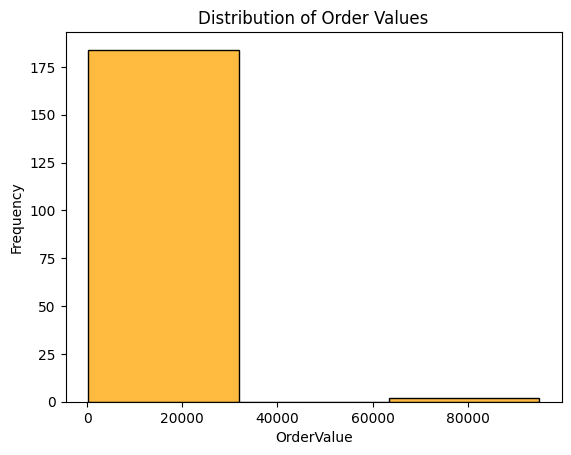

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["order_value"],bins =3,color = "orange")
plt.xlabel("OrderValue")
plt.ylabel("Frequency")
plt.title("Distribution of Order Values")
plt.show()

Q3. plot a box plot for the delivery days columns

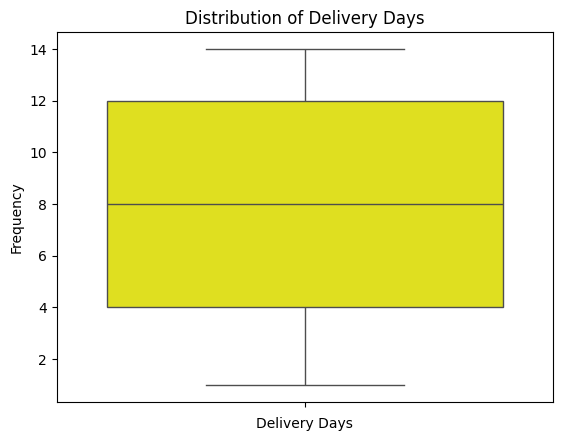

In [18]:
#plt.boxplot(data["delivery_days"])
sns.boxplot(data["delivery_days"],color = 'yellow')
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Days")
plt.show()

Task 3 . Correlation Analysis

Q1.Compute the correlation matrix for all numerical columns using df.corr()

In [22]:
import numpy as np
corr = df.select_dtypes(include=np.number).corr()
corr

,order_id,order_value,delivery_days,rating
order_id,1.000000,-0.092871,0.004779,0.035212
order_value,-0.092871,1.000000,0.137994,-0.071752
delivery_days,0.004779,0.137994,1.000000,-0.040863
rating,0.035212,-0.071752,-0.040863,1.000000


Q2. plot the heatmap of the correlation matrix with annotation values

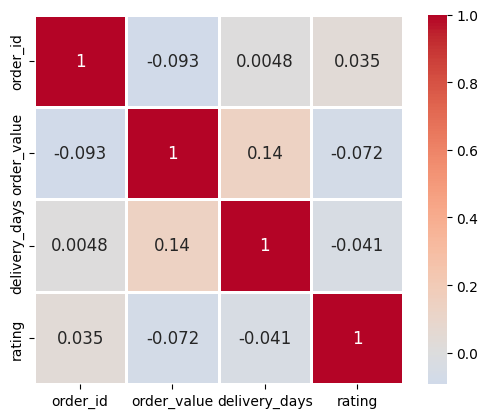

In [23]:
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, square=True, linewidths=1, annot_kws={'fontsize': 12})
plt.show()

Q3.write a observation from the heatmap

    order_value vs delivery_days this is the strongest non-self correlation thought it is still consideed a very weak positive
    correlation . it suggests that are order value increases .
    delivery days might slightly increases but is relationship is not
    strong


    ration correlation is no correlation with the order_value(-0.072) or delivery_days(-0.041)
